# Dog vs Cat Classification with DeepLab Segmentation

This notebook uses `data/oxford-iiit-pet/annotations/list.txt` for binary species labels. A CNN learns to classify each full image as cat or dog, and the saved DeepLabv3+ segmentation checkpoint is loaded so the same image can also be segmented.

In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import InterpolationMode

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "oxford-iiit-pet"
IMAGE_DIR = DATA_ROOT / "images"
ANNOTATION_DIR = DATA_ROOT / "annotations"
LIST_PATH = ANNOTATION_DIR / "list.txt"
DEEPLAB_CHECKPOINT = PROJECT_ROOT / "best_pet_segmentation_cnn.pt"
CLASSIFIER_CHECKPOINT = PROJECT_ROOT / "best_dog_cat_classifier_cnn.pt"

SEED = 42
IMAGE_SIZE = 160
BATCH_SIZE = 32
EPOCHS = 12
LEARNING_RATE = 1e-3
NUM_WORKERS = 0

MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)
SPECIES_NAMES = ["cat", "dog"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load Binary Labels

`list.txt` has columns `image`, `class_id`, `species`, and `breed_id`. The species column is already binary: `1` means cat and `2` means dog. The classifier target below remaps those values to `0` and `1`.

In [2]:
def load_species_table(list_path=LIST_PATH):
    rows = []
    with list_path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            image_id, class_id, species, breed_id = line.split()
            image_path = IMAGE_DIR / f"{image_id}.jpg"
            trimap_path = ANNOTATION_DIR / "trimaps" / f"{image_id}.png"
            if image_path.exists():
                species_id = int(species)
                rows.append(
                    {
                        "image_id": image_id,
                        "image_path": image_path,
                        "trimap_path": trimap_path,
                        "class_id": int(class_id),
                        "species": species_id,
                        "target": species_id - 1,
                        "label": SPECIES_NAMES[species_id - 1],
                        "breed_id": int(breed_id),
                    }
                )
    return pd.DataFrame(rows)


metadata = load_species_table()
print(metadata.shape)

class_distribution = metadata["label"].value_counts().rename_axis("label").to_frame("count")
class_distribution["fraction"] = class_distribution["count"] / class_distribution["count"].sum()
class_distribution

(7349, 8)


,count,fraction
label,,
dog,4978,0.677371
cat,2371,0.322629


In [3]:
def stratified_split(df, train_fraction=0.7, val_fraction=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    train_indices, val_indices, test_indices = [], [], []

    for _, group in df.groupby("target"):
        indices = group.index.to_numpy()
        rng.shuffle(indices)
        train_end = int(len(indices) * train_fraction)
        val_end = train_end + int(len(indices) * val_fraction)
        train_indices.extend(indices[:train_end])
        val_indices.extend(indices[train_end:val_end])
        test_indices.extend(indices[val_end:])

    return sorted(train_indices), sorted(val_indices), sorted(test_indices)


train_idx, val_idx, test_idx = stratified_split(metadata)
split_counts = pd.Series({"train": len(train_idx), "val": len(val_idx), "test": len(test_idx)})
split_counts

train    5143
val      1101
test     1105
dtype: int64

## Dataset and Classifier CNN

The dataset has more dog images than cat images. To compensate, the training loader uses a weighted sampler that samples minority-class examples more often. Validation and test loaders stay unbalanced so the metrics still describe the real holdout data.

In [4]:
train_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)

eval_transform = transforms.Compose(
    [
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD),
    ]
)


class PetSpeciesDataset(Dataset):
    def __init__(self, table, transform=None):
        self.table = table.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]
        image = Image.open(row.image_path).convert("RGB")
        tensor = self.transform(image) if self.transform else transforms.ToTensor()(image)
        target = torch.tensor(row.target, dtype=torch.long)
        return tensor, target, row.image_id


train_dataset = PetSpeciesDataset(metadata.iloc[train_idx], transform=train_transform)
val_dataset = PetSpeciesDataset(metadata.iloc[val_idx], transform=eval_transform)
test_dataset = PetSpeciesDataset(metadata.iloc[test_idx], transform=eval_transform)

USE_WEIGHTED_SAMPLER = True
USE_CLASS_WEIGHTED_LOSS = False

train_targets = metadata.iloc[train_idx]["target"].to_numpy()
train_class_counts = np.bincount(train_targets, minlength=len(SPECIES_NAMES))
sample_weights = 1.0 / train_class_counts[train_targets]
train_sampler = WeightedRandomSampler(
    weights=torch.as_tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True,
)
class_weights = train_class_counts.sum() / (len(SPECIES_NAMES) * train_class_counts)
class_weights = torch.as_tensor(class_weights, dtype=torch.float32, device=device)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=not USE_WEIGHTED_SAMPLER,
    sampler=train_sampler if USE_WEIGHTED_SAMPLER else None,
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

pd.DataFrame(
    {
        "label": SPECIES_NAMES,
        "train_count": train_class_counts,
        "loss_weight": class_weights.detach().cpu().numpy(),
    }
)

,label,train_count,loss_weight
0,cat,1659,1.550030
1,dog,3484,0.738088


In [5]:
class DogCatCNN(nn.Module):
    def __init__(self, num_classes=2, dropout=0.35):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


classifier = DogCatCNN().to(device)
sum(parameter.numel() for parameter in classifier.parameters() if parameter.requires_grad)

583394

## Train the Dog/Cat CNN

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    correct = 0
    total = 0
    class_correct = torch.zeros(len(SPECIES_NAMES), dtype=torch.long)
    class_total = torch.zeros(len(SPECIES_NAMES), dtype=torch.long)

    for images, targets, _ in loader:
        images = images.to(device)
        targets = targets.to(device)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, targets)
            if training:
                loss.backward()
                optimizer.step()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        predictions = logits.argmax(dim=1)
        correct += (predictions == targets).sum().item()
        total += batch_size

        for class_index in range(len(SPECIES_NAMES)):
            class_mask = targets.cpu() == class_index
            class_total[class_index] += class_mask.sum()
            class_correct[class_index] += (predictions.cpu()[class_mask] == class_index).sum()

    class_accuracy = class_correct.float() / class_total.clamp_min(1).float()
    metrics = {"loss": total_loss / total, "accuracy": correct / total}
    metrics["balanced_accuracy"] = class_accuracy.mean().item()
    for class_index, class_name in enumerate(SPECIES_NAMES):
        metrics[f"{class_name}_accuracy"] = class_accuracy[class_index].item()
    return metrics


criterion = nn.CrossEntropyLoss(weight=class_weights if USE_CLASS_WEIGHTED_LOSS else None)
optimizer = torch.optim.AdamW(classifier.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history = []
best_val_balanced_accuracy = -1.0

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(classifier, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_epoch(classifier, val_loader, criterion)
    scheduler.step()

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_accuracy": train_metrics["accuracy"],
        "train_balanced_accuracy": train_metrics["balanced_accuracy"],
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_cat_accuracy": val_metrics["cat_accuracy"],
        "val_dog_accuracy": val_metrics["dog_accuracy"],
    }
    history.append(row)
    print(row)

    if val_metrics["balanced_accuracy"] > best_val_balanced_accuracy:
        best_val_balanced_accuracy = val_metrics["balanced_accuracy"]
        torch.save(
            {
                "model_name": "DogCatCNN",
                "state_dict": classifier.state_dict(),
                "image_size": IMAGE_SIZE,
                "mean": MEAN,
                "std": STD,
                "class_names": SPECIES_NAMES,
                "validation_metrics": val_metrics,
                "imbalance_handling": {
                    "weighted_sampler": USE_WEIGHTED_SAMPLER,
                    "class_weighted_loss": USE_CLASS_WEIGHTED_LOSS,
                    "train_class_counts": train_class_counts.tolist(),
                    "class_weights": class_weights.detach().cpu().tolist(),
                },
                "seed": SEED,
            },
            CLASSIFIER_CHECKPOINT,
        )

history_df = pd.DataFrame(history)
history_df

{'epoch': 1, 'train_loss': 0.6697784028186794, 'train_accuracy': 0.5951779117246743, 'train_balanced_accuracy': 0.5961087942123413, 'val_loss': 0.617673535654482, 'val_accuracy': 0.6385104450499546, 'val_balanced_accuracy': 0.6321092844009399, 'val_cat_accuracy': 0.6140844821929932, 'val_dog_accuracy': 0.6501340270042419}
{'epoch': 2, 'train_loss': 0.6496320067387529, 'train_accuracy': 0.622982694925141, 'train_balanced_accuracy': 0.622917652130127, 'val_loss': 0.6167609402529225, 'val_accuracy': 0.6666666666666666, 'val_balanced_accuracy': 0.6189291477203369, 'val_cat_accuracy': 0.4845070540904999, 'val_dog_accuracy': 0.7533512115478516}
{'epoch': 3, 'train_loss': 0.6359571794139581, 'train_accuracy': 0.6385378183939335, 'train_balanced_accuracy': 0.6384098529815674, 'val_loss': 0.6231631359574363, 'val_accuracy': 0.6930063578564941, 'val_balanced_accuracy': 0.5505192279815674, 'val_cat_accuracy': 0.14929577708244324, 'val_dog_accuracy': 0.9517426490783691}
{'epoch': 4, 'train_loss': 

,epoch,train_loss,train_accuracy,train_balanced_accuracy,val_loss,val_accuracy,val_balanced_accuracy,val_cat_accuracy,val_dog_accuracy
0,1,0.669778,0.595178,0.596109,0.617674,0.638510,0.632109,0.614084,0.650134
1,2,0.649632,0.622983,0.622918,0.616761,0.666667,0.618929,0.484507,0.753351
2,3,0.635957,0.638538,0.638410,0.623163,0.693006,0.550519,0.149296,0.951743
3,4,0.617315,0.657982,0.658070,0.641466,0.613987,0.656829,0.777465,0.536193
4,5,0.589748,0.691425,0.691497,0.789890,0.487738,0.608696,0.949296,0.268097
5,6,0.557296,0.714175,0.714121,0.738171,0.574024,0.668678,0.935211,0.402145
6,7,0.543512,0.733035,0.733078,0.529093,0.735695,0.749594,0.788732,0.710456
7,8,0.473484,0.785534,0.785709,0.570604,0.704814,0.749690,0.876056,0.623324
8,9,0.445552,0.800311,0.800214,0.495883,0.775658,0.790158,0.830986,0.749330
9,10,0.414461,0.822672,0.822752,0.397897,0.822888,0.810246,0.774648,0.845845


In [7]:
classifier_checkpoint = torch.load(CLASSIFIER_CHECKPOINT, map_location=device)
classifier.load_state_dict(classifier_checkpoint["state_dict"])
test_metrics = run_epoch(classifier, test_loader, criterion)
test_metrics

{'loss': 0.429933903551749,
 'accuracy': 0.8063348416289593,
 'balanced_accuracy': 0.822542667388916,
 'cat_accuracy': 0.8683473467826843,
 'dog_accuracy': 0.7767379879951477}

## Load the Saved DeepLabv3+ Segmenter

In [8]:
def make_group_norm(num_channels, max_groups=8):
    groups = min(max_groups, num_channels)
    while groups > 1 and (num_channels % groups != 0 or num_channels // groups < 2):
        groups -= 1
    return nn.GroupNorm(groups, num_channels)


class ConvNormAct(nn.Sequential):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=None, dilation=1):
        if padding is None:
            padding = dilation * (kernel_size // 2)
        super().__init__(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                dilation=dilation,
                bias=False,
            ),
            make_group_norm(out_channels),
            nn.ReLU(inplace=True),
        )


class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dilation=1):
        super().__init__()
        self.block = nn.Sequential(
            ConvNormAct(in_channels, out_channels, dilation=dilation),
            ConvNormAct(out_channels, out_channels, dilation=dilation),
        )

    def forward(self, x):
        return self.block(x)


class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=128, rates=(1, 6, 12, 18), dropout=0.1):
        super().__init__()
        branches = []
        for rate in rates:
            if rate == 1:
                branches.append(ConvNormAct(in_channels, out_channels, kernel_size=1, padding=0))
            else:
                branches.append(ConvNormAct(in_channels, out_channels, kernel_size=3, dilation=rate))
        self.branches = nn.ModuleList(branches)
        self.image_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            ConvNormAct(in_channels, out_channels, kernel_size=1, padding=0),
        )
        self.project = nn.Sequential(
            ConvNormAct(out_channels * (len(rates) + 1), out_channels, kernel_size=1, padding=0),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        size = x.shape[-2:]
        outputs = [branch(x) for branch in self.branches]
        pooled = self.image_pool(x)
        pooled = F.interpolate(pooled, size=size, mode="bilinear", align_corners=False)
        outputs.append(pooled)
        return self.project(torch.cat(outputs, dim=1))


class DeepLabV3Plus(nn.Module):
    def __init__(self, num_classes=3, base_channels=32, aspp_channels=128, decoder_channels=128, low_channels=48, rates=(1, 6, 12, 18)):
        super().__init__()
        self.stem = DoubleConv(3, base_channels)
        self.stage2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_channels, base_channels * 2))
        self.stage3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base_channels * 2, base_channels * 4))
        self.stage4 = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(base_channels * 4, base_channels * 8),
            ConvNormAct(base_channels * 8, base_channels * 8, dilation=2),
            ConvNormAct(base_channels * 8, base_channels * 8, dilation=4),
        )
        self.aspp = ASPP(base_channels * 8, aspp_channels, rates=rates)
        self.low_project = ConvNormAct(base_channels * 2, low_channels, kernel_size=1, padding=0)
        self.decoder = nn.Sequential(
            DoubleConv(aspp_channels + low_channels, decoder_channels),
            nn.Conv2d(decoder_channels, num_classes, kernel_size=1),
        )

    def forward(self, x):
        input_size = x.shape[-2:]
        x = self.stem(x)
        low = self.stage2(x)
        x = self.stage3(low)
        high = self.stage4(x)
        high = self.aspp(high)
        high = F.interpolate(high, size=low.shape[-2:], mode="bilinear", align_corners=False)
        low = self.low_project(low)
        logits = self.decoder(torch.cat([low, high], dim=1))
        return F.interpolate(logits, size=input_size, mode="bilinear", align_corners=False)


In [9]:
segmentation_checkpoint = torch.load(DEEPLAB_CHECKPOINT, map_location=device)
segmenter = DeepLabV3Plus(
    num_classes=len(segmentation_checkpoint["class_names"]),
    **segmentation_checkpoint["model_kwargs"],
).to(device)
segmenter.load_state_dict(segmentation_checkpoint["state_dict"])
segmenter.eval()

segmentation_transform = transforms.Compose(
    [
        transforms.Resize((segmentation_checkpoint["image_size"], segmentation_checkpoint["image_size"]), interpolation=InterpolationMode.BILINEAR),
        transforms.ToTensor(),
        transforms.Normalize(segmentation_checkpoint["mean"], segmentation_checkpoint["std"]),
    ]
)

segmentation_checkpoint["model_kwargs"], segmentation_checkpoint["test_metrics"]

({'base_channels': 24,
  'aspp_channels': 96,
  'decoder_channels': 128,
  'low_channels': 48,
  'rates': (1, 4, 8, 12)},
 {'pixel_acc': 0.8773619532585144,
  'mean_iou': 0.7126386165618896,
  'mean_dice': 0.8205893039703369,
  'class_iou': [0.7775111198425293, 0.874888002872467, 0.48551681637763977],
  'class_dice': [0.8748311996459961, 0.9332696199417114, 0.653667151927948],
  'loss': 0.3141411415609166})

## Classify and Segment the Same Image

In [10]:
def denormalize(tensor, mean=MEAN, std=STD):
    mean_tensor = torch.tensor(mean, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=tensor.dtype, device=tensor.device).view(3, 1, 1)
    return (tensor * std_tensor + mean_tensor).clamp(0, 1)


def predict_species(image):
    classifier.eval()
    tensor = eval_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probabilities = classifier(tensor).softmax(dim=1).squeeze(0).cpu()
    predicted_index = int(probabilities.argmax())
    return SPECIES_NAMES[predicted_index], probabilities


def segment_image(image):
    original_size = image.size[::-1]
    tensor = segmentation_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = segmenter(tensor)
        prediction = logits.argmax(dim=1).squeeze(0).cpu().numpy().astype(np.uint8)
    prediction_image = Image.fromarray(prediction).resize(image.size, resample=Image.Resampling.NEAREST)
    return np.array(prediction_image)


def colorize_trimap(mask):
    colors = np.array(
        [
            [64, 180, 120],   # pet foreground
            [40, 80, 180],    # background
            [240, 190, 70],   # boundary
        ],
        dtype=np.uint8,
    )
    return colors[mask]


def overlay_mask(image, mask, alpha=0.45):
    image_array = np.array(image).astype(np.float32)
    mask_rgb = colorize_trimap(mask).astype(np.float32)
    return np.clip((1 - alpha) * image_array + alpha * mask_rgb, 0, 255).astype(np.uint8)


def classify_and_segment(image_id):
    row = metadata.loc[metadata["image_id"] == image_id].iloc[0]
    image = Image.open(row.image_path).convert("RGB")
    predicted_label, probabilities = predict_species(image)
    predicted_mask = segment_image(image)
    return {
        "image_id": image_id,
        "true_label": row.label,
        "predicted_label": predicted_label,
        "cat_probability": float(probabilities[0]),
        "dog_probability": float(probabilities[1]),
        "image": image,
        "mask": predicted_mask,
        "overlay": overlay_mask(image, predicted_mask),
    }


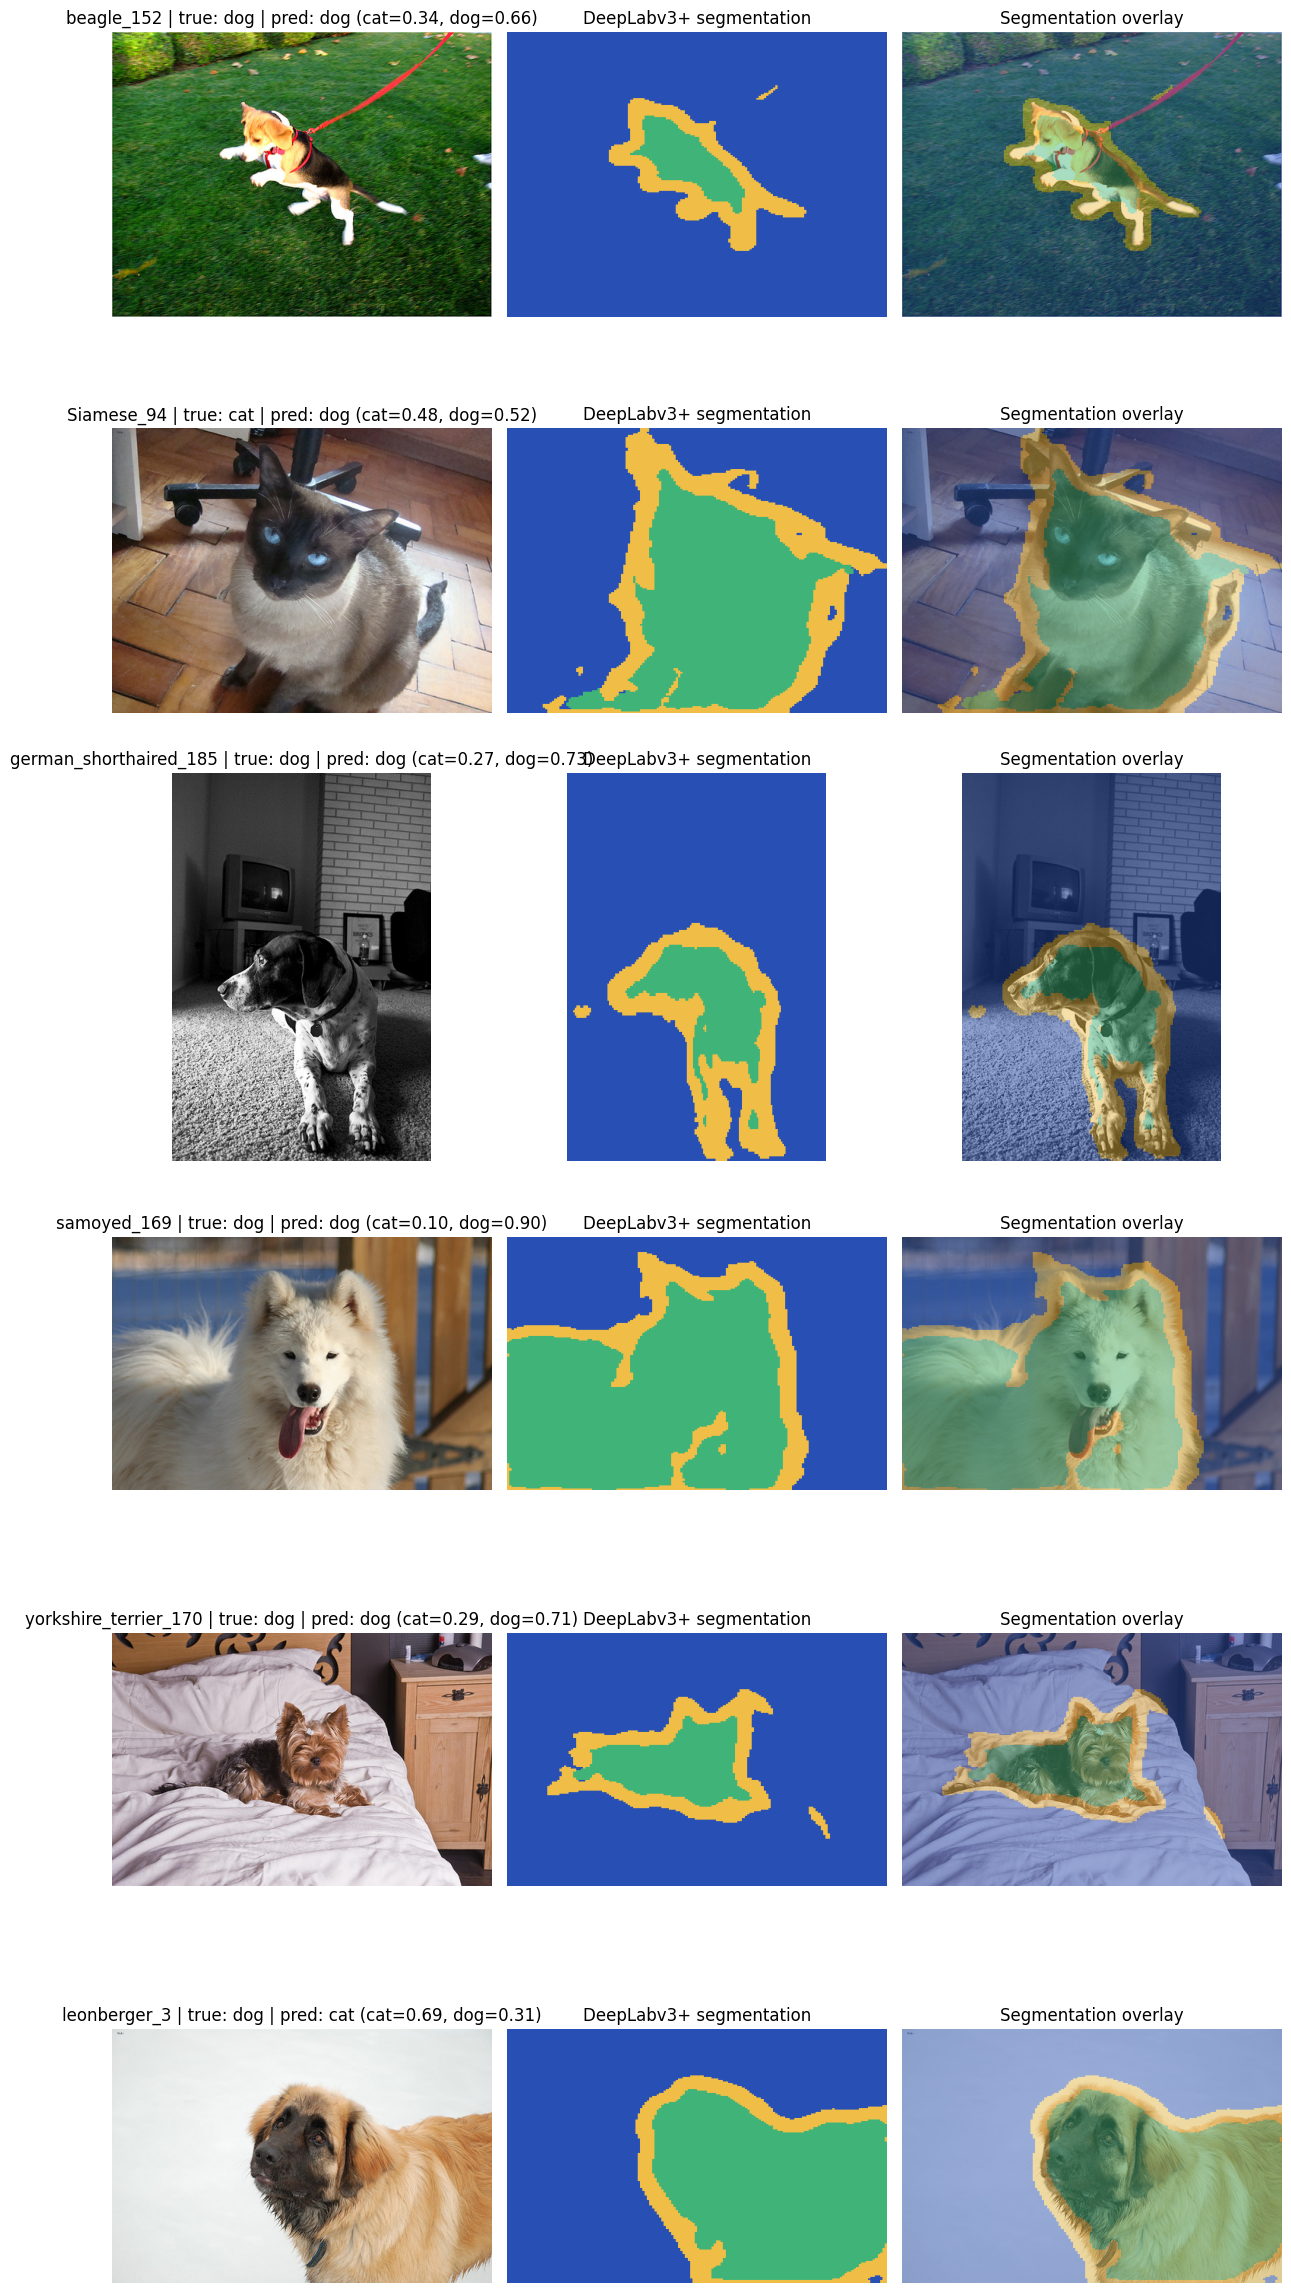

In [11]:
sample_ids = metadata.iloc[test_idx].sample(6, random_state=SEED)["image_id"].tolist()
results = [classify_and_segment(image_id) for image_id in sample_ids]

fig, axes = plt.subplots(len(results), 3, figsize=(12, 4 * len(results)))
if len(results) == 1:
    axes = axes[None, :]

for row_axes, result in zip(axes, results):
    title = (
        f"{result['image_id']} | true: {result['true_label']} | "
        f"pred: {result['predicted_label']} "
        f"(cat={result['cat_probability']:.2f}, dog={result['dog_probability']:.2f})"
    )
    row_axes[0].imshow(result["image"])
    row_axes[0].set_title(title)
    row_axes[1].imshow(colorize_trimap(result["mask"]))
    row_axes[1].set_title("DeepLabv3+ segmentation")
    row_axes[2].imshow(result["overlay"])
    row_axes[2].set_title("Segmentation overlay")
    for ax in row_axes:
        ax.axis("off")

plt.tight_layout()

The classifier and segmenter are intentionally separate models. The CNN predicts the image-level `cat` or `dog` label from `list.txt`; the DeepLabv3+ checkpoint predicts pixel-level `pet`, `background`, and `boundary` regions for the same image.